In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- QUTIP IMPORTS ---
import qutip as qt

# --- QISKIT IMPORTS ---
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ==========================================
# 0. SIMULATION PARAMETERS
# ==========================================
N = 4                # Number of qubits (spins)
total_time = 4.0     # Total simulation time
num_steps = 200      # Number of Trotter steps (higher = more accurate Qiskit)
time_steps = np.linspace(0, total_time, num_steps)
dt = total_time / (num_steps - 1)

# Physics parameters (Critical point is roughly J = h)
J = 1.0              # ZZ coupling strength
h = 1.0              # Transverse field strength

print(f"TFIM Many-Body Benchmark: N={N} qubits, dt={dt:.4f}")
print(f"Hamiltonian: H = -{J} Σ(ZZ) - {h} Σ(X)")

TFIM Many-Body Benchmark: N=4 qubits, dt=0.0201
Hamiltonian: H = -1.0 Σ(ZZ) - 1.0 Σ(X)


In [2]:
# ==========================================
# 1. QUTIP SIMULATION (Exact Continuous)
# ==========================================

# Helper function to create an N-qubit operator
def make_n_qubit_op(single_op, position, N):
    ops = [qt.qeye(2)] * N
    ops[position] = single_op
    return qt.tensor(ops)

# Build the TFIM Hamiltonian
H_qutip = 0

# 1. ZZ interactions: -J * Z_i * Z_{i+1}
for i in range(N - 1):
    Z_i = make_n_qubit_op(qt.sigmaz(), i, N)
    Z_ip1 = make_n_qubit_op(qt.sigmaz(), i + 1, N)
    H_qutip += -J * (Z_i * Z_ip1)

# 2. Transverse field: -h * X_i
for i in range(N):
    X_i = make_n_qubit_op(qt.sigmax(), i, N)
    H_qutip += -h * X_i

# Initial state: |0000> (All spins UP)
psi0 = qt.tensor([qt.basis(2, 0)] * N)

# Observable: Local magnetization of the first spin <Z_0>
Z_0_op = make_n_qubit_op(qt.sigmaz(), 0, N)

# Solve (using sesolve for pure state, much faster than mesolve)
qutip_result = qt.sesolve(H_qutip, psi0, time_steps, [Z_0_op])
qutip_exp_z0 = qutip_result.expect[0]

print("✅ QuTiP exact simulation completed.")

✅ QuTiP exact simulation completed.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [4]:
# ==========================================
# 2. QISKIT SIMULATION (Trotterized Gates)
# ==========================================
from qiskit.quantum_info import SparsePauliOp

qiskit_exp_z0 = []

# Initialize statevector simulator (exact, no hardware noise, just Trotter error)
simulator = AerSimulator(method='statevector')

# Pre-calculate gate angles
# Qiskit RZZ(theta) = exp(-i * theta/2 * Z⊗Z). We want exp(i * J * dt * Z⊗Z) -> theta = -2*J*dt
theta_rzz = -2.0 * J * dt 
# Qiskit RX(theta) = exp(-i * theta/2 * X). We want exp(i * h * dt * X) -> theta = -2*h*dt
theta_rx = -2.0 * h * dt

# FIX & UPGRADE: Define the observable using SparsePauliOp
# In Qiskit's Pauli string notation, the rightmost character is qubit 0.
# So, a Z operator on qubit 0 for N qubits is "II...IZ"
z0_label = "I" * (N - 1) + "Z"
Z_0_op = SparsePauliOp.from_list([(z0_label, 1.0)])

for step in range(num_steps):
    qc = QuantumCircuit(N)
    
    # Apply 'step' layers of 1st-order Trotterization
    for _ in range(step):
        # 1. ZZ Interactions (Nearest Neighbor)
        for i in range(N - 1):
            qc.rzz(theta_rzz, i, i + 1)
            
        # 2. Transverse Field (Single Qubit)
        for i in range(N):
            qc.rx(theta_rx, i)
            
    # Save the final statevector
    qc.save_statevector()
    
    # Execute
    result = simulator.run(qc).result()
    psi = result.get_statevector()
    
    # FIX: Use Qiskit's built-in expectation_value method.
    # This natively handles the Statevector object and is highly memory efficient.
    exp_z0 = np.real(psi.expectation_value(Z_0_op))
    qiskit_exp_z0.append(exp_z0)

print("✅ Qiskit Trotter simulation completed.")

✅ Qiskit Trotter simulation completed.



--- BENCHMARK RESULTS ---
Max Deviation (QuTiP vs Qiskit): 5.3617e-04


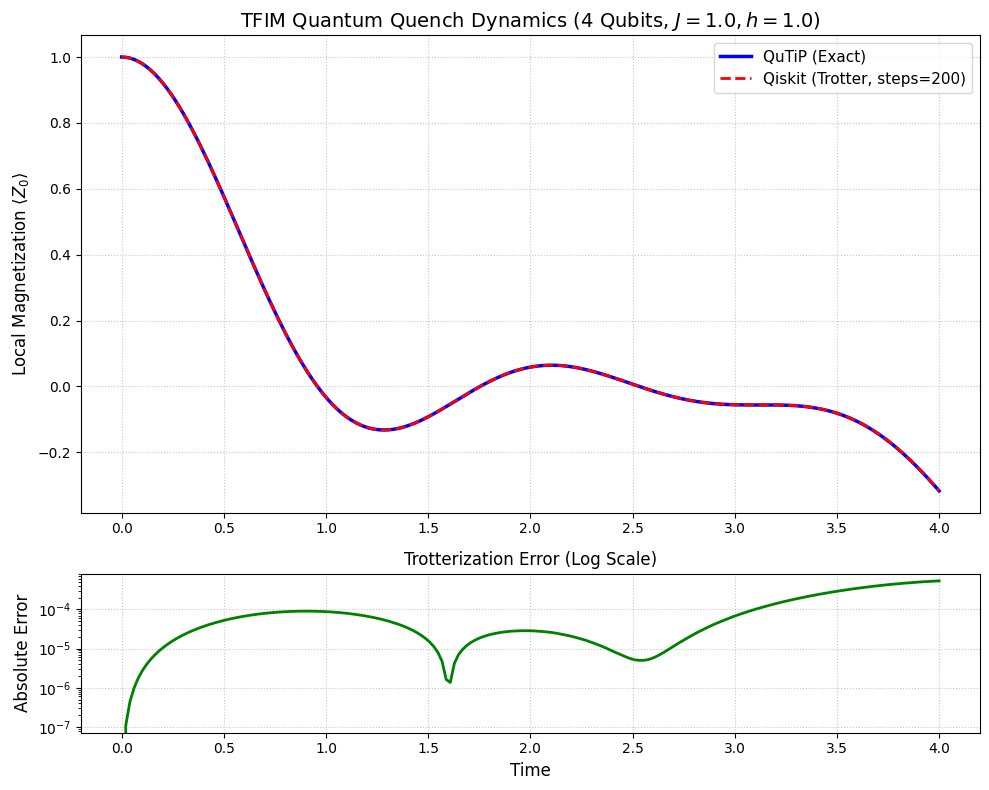

In [5]:
# ==========================================
# 3. ACCURACY BENCHMARK & PLOTTING
# ==========================================

# Calculate error
errors = np.abs(np.array(qutip_exp_z0) - np.array(qiskit_exp_z0))
max_error = np.max(errors)

print(f"\n--- BENCHMARK RESULTS ---")
print(f"Max Deviation (QuTiP vs Qiskit): {max_error:.4e}")

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

# Top Plot: Dynamics
ax1.plot(time_steps, qutip_exp_z0, 'b-', label='QuTiP (Exact)', linewidth=2.5)
ax1.plot(time_steps, qiskit_exp_z0, 'r--', label=f'Qiskit (Trotter, steps={num_steps})', linewidth=2)
ax1.set_title(f'TFIM Quantum Quench Dynamics ({N} Qubits, $J={J}, h={h}$)', fontsize=14)
ax1.set_ylabel(r'Local Magnetization $\langle Z_0 \rangle$', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(fontsize=11)

# Bottom Plot: Error
ax2.plot(time_steps, errors, 'g-', linewidth=2)
ax2.set_yscale('log')
ax2.set_title('Trotterization Error (Log Scale)', fontsize=12)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Absolute Error', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()